# Result Evaluation: Granular Closeness Analysis

This notebook explains *why* closeness-metric scores look the way they do by drilling down from dataset-level averages to topic-job interactions.

## What this notebook covers
1. Train CS and IT topic models from course skills
2. Score each job against every topic (not only best topic)
3. Compare topics to related job titles using overlap and score metrics
4. Inspect selected jobs in detail (best topic, runner-up, margin, contributing words)
5. Compare one job against all topics to see alignment profile
6. Summarize drivers of final scores (distribution, weak docs, topic concentration)

In [14]:
import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gensim.corpora import Dictionary
from gensim.models import LdaModel

pd.set_option('display.max_colwidth', 120)
np.set_printoptions(suppress=True)

In [15]:
# Paths
BASE = Path('..').resolve()
OUT = BASE / 'out'
DATA = BASE / 'data'

CS_COURSE_PATH = OUT / 'cs_course_skills.jsonl'
IT_COURSE_PATH = OUT / 'it_course_skills.jsonl'

CS_LOCAL_JOBS_PATH = OUT / 'local_cs_skills.jsonl'
CS_INTL_JOBS_PATH = OUT / 'international_cs_skills.jsonl'
IT_LOCAL_JOBS_PATH = OUT / 'local_it_skills.jsonl'
IT_INTL_JOBS_PATH = OUT / 'international_it_skills.jsonl'

UNRELATED_JOBS_PATH = OUT / 'unrelated_skills.jsonl'
AI_JOBS_PATH = OUT / 'ai_skills.jsonl'

LOCAL_DESC_PATH = DATA / 'processed' / 'processed_jobs.jsonl'
INTL_DESC_PATH = DATA / 'processed' / 'linkedin_jobs_preprocessed.jsonl'

required = [
    CS_COURSE_PATH, IT_COURSE_PATH,
    CS_LOCAL_JOBS_PATH, CS_INTL_JOBS_PATH,
    IT_LOCAL_JOBS_PATH, IT_INTL_JOBS_PATH,
    UNRELATED_JOBS_PATH, AI_JOBS_PATH
]

for path in required:
    if not path.exists():
        raise FileNotFoundError(f'Missing: {path}')

print('All required files found.')

All required files found.


In [16]:
# Data loading
cs_course_df = pd.read_json(CS_COURSE_PATH, lines=True)
it_course_df = pd.read_json(IT_COURSE_PATH, lines=True)

cs_local_df = pd.read_json(CS_LOCAL_JOBS_PATH, lines=True)
cs_intl_df = pd.read_json(CS_INTL_JOBS_PATH, lines=True)
it_local_df = pd.read_json(IT_LOCAL_JOBS_PATH, lines=True)
it_intl_df = pd.read_json(IT_INTL_JOBS_PATH, lines=True)

unrelated_df = pd.read_json(UNRELATED_JOBS_PATH, lines=True)
ai_df = pd.read_json(AI_JOBS_PATH, lines=True)

display(pd.DataFrame([
    ['CS Courses', len(cs_course_df)],
    ['IT Courses', len(it_course_df)],
    ['CS Local Jobs', len(cs_local_df)],
    ['CS International Jobs', len(cs_intl_df)],
    ['IT Local Jobs', len(it_local_df)],
    ['IT International Jobs', len(it_intl_df)],
    ['Unrelated Jobs', len(unrelated_df)],
    ['AI Jobs', len(ai_df)],
], columns=['Dataset', 'Rows']))

,Dataset,Rows
0,CS Courses,37
1,IT Courses,31
2,CS Local Jobs,13
3,CS International Jobs,1315
4,IT Local Jobs,13
5,IT International Jobs,1354
6,Unrelated Jobs,1634
7,AI Jobs,1093


In [17]:
# Optional job-description sources (best-effort attachment for explainability)
desc_frames = []
for p in [LOCAL_DESC_PATH, INTL_DESC_PATH]:
    if p.exists():
        d = pd.read_json(p, lines=True)
        if 'clean_text' in d.columns and 'job_title' in d.columns:
            keep = [c for c in ['region', 'job_category', 'job_title', 'clean_text'] if c in d.columns]
            desc_frames.append(d[keep].copy())

if desc_frames:
    desc_df = pd.concat(desc_frames, ignore_index=True).drop_duplicates()
else:
    desc_df = pd.DataFrame(columns=['region', 'job_category', 'job_title', 'clean_text'])

print('Description rows available:', len(desc_df))

Description rows available: 3085


In [18]:
# Preparation and scoring helpers
def normalize_multiword_skills(skills):
    if not isinstance(skills, list):
        return []
    return [str(skill).strip().replace(' ', '_') for skill in skills if str(skill).strip()]

def clean_tokens(tokens):
    return [t for t in tokens if t not in {'computer_science', 'information_technology'}]

def prepare_texts(df):
    texts = df['skills'].apply(normalize_multiword_skills).tolist()
    texts = [clean_tokens(t) for t in texts]
    return [t for t in texts if len(t) > 0]

def train_lda(skills, num_topics, no_below=1, no_above=0.95):
    dictionary = Dictionary(skills)
    dictionary.filter_extremes(no_below=no_below, no_above=no_above)
    corpus = [dictionary.doc2bow(skill) for skill in skills]
    model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=42,
        passes=10,
        iterations=100
    )
    return {'dictionary': dictionary, 'corpus': corpus, 'model': model}

def get_topic_word_probs(model, num_topics, num_words=50):
    topics = model.show_topics(num_topics=num_topics, num_words=num_words, formatted=False)
    return {topic_id: dict(word_probs) for topic_id, word_probs in topics}

def score_document_against_topics(doc_tokens, topic_word_probs):
    counts = Counter(doc_tokens)
    topic_scores = {}
    overlap_counts = {}

    for topic_id, word_probs in topic_word_probs.items():
        s = 0.0
        overlap = 0
        for word, prob in word_probs.items():
            if word in counts:
                s += counts[word] * prob
                overlap += 1
        topic_scores[topic_id] = s
        overlap_counts[topic_id] = overlap

    sorted_topics = sorted(topic_scores.items(), key=lambda x: x[1], reverse=True)
    best_topic, best_score = sorted_topics[0]
    second_score = sorted_topics[1][1] if len(sorted_topics) > 1 else 0.0

    return {
        'topic_scores': topic_scores,
        'overlap_counts': overlap_counts,
        'best_topic': best_topic,
        'best_score': best_score,
        'second_score': second_score,
        'margin': best_score - second_score,
        'normalized_best_score': best_score / max(1, len(doc_tokens)),
        'best_overlap_count': overlap_counts[best_topic],
    }

def attach_description(jobs_df, desc_df):
    out = jobs_df.copy()
    out['job_title_norm'] = out['job_title'].astype(str).str.strip().str.lower()

    if len(desc_df) == 0:
        out['clean_text'] = ''
        return out.drop(columns=['job_title_norm'])

    d = desc_df.copy()
    d['job_title_norm'] = d['job_title'].astype(str).str.strip().str.lower()

    merged = out.merge(
        d[['job_title_norm', 'clean_text']].drop_duplicates('job_title_norm'),
        how='left',
        on='job_title_norm'
    )

    merged['clean_text'] = merged['clean_text'].fillna('')
    return merged.drop(columns=['job_title_norm'])

In [19]:
# Build CS and IT topic models from course skills
CS_NUM_TOPICS = 18
IT_NUM_TOPICS = 18

cs_course_texts = prepare_texts(cs_course_df)
it_course_texts = prepare_texts(it_course_df)

cs_lda = train_lda(cs_course_texts, CS_NUM_TOPICS)
it_lda = train_lda(it_course_texts, IT_NUM_TOPICS)

cs_topic_word_probs = get_topic_word_probs(cs_lda['model'], CS_NUM_TOPICS, num_words=50)
it_topic_word_probs = get_topic_word_probs(it_lda['model'], IT_NUM_TOPICS, num_words=50)

print('CS topics:', CS_NUM_TOPICS, '| IT topics:', IT_NUM_TOPICS)

CS topics: 18 | IT topics: 18


In [27]:
# Print topics before detailed results
def print_topics(model_dict, label, num_words=12):
    model = model_dict['model']
    topics = model.print_topics(num_words=num_words)
    print(f"\n{label} Topics (top {num_words} words each)")
    print("=" * 80)
    for topic_num, topic_words in topics:
        print(f"Topic {topic_num}: {topic_words}")

print_topics(cs_lda, "Computer Science", num_words=12)
print_topics(it_lda, "Information Technology", num_words=12)


Computer Science Topics (top 12 words each)
Topic 0: 0.008*"cognitive_model" + 0.008*"interaction_design" + 0.008*"teamwork" + 0.008*"online_communities" + 0.008*"social_medium" + 0.008*"presentations" + 0.004*"parallel_processing" + 0.004*"communication_system" + 0.004*"route_protocol" + 0.004*"application_level" + 0.004*"access_network" + 0.004*"client_server"
Topic 1: 0.011*"management_system" + 0.011*"sql" + 0.011*"database_management_system" + 0.006*"programming" + 0.006*"algorithms" + 0.006*"collision_detection" + 0.006*"virtual_reality" + 0.006*"distribution_functions" + 0.006*"time_series" + 0.006*"model_building" + 0.006*"random_numbers" + 0.006*"data_definition"
Topic 2: 0.023*"develop_software" + 0.023*"project_management" + 0.023*"software_system" + 0.016*"milestones" + 0.016*"apply_research" + 0.016*"software_documentation" + 0.016*"timelines" + 0.016*"project_plan" + 0.016*"problem_solve" + 0.016*"design_solutions" + 0.016*"system_software" + 0.016*"project_planning"
Top

In [20]:
# Build scored job-level frames
def build_scored_jobs(jobs_df, topic_word_probs, label, desc_df):
    jobs = attach_description(jobs_df, desc_df).copy()
    jobs['tokens'] = jobs['skills'].apply(normalize_multiword_skills).apply(clean_tokens)

    metrics = []
    for tokens in jobs['tokens']:
        m = score_document_against_topics(tokens, topic_word_probs)
        metrics.append(m)

    mdf = pd.DataFrame(metrics)
    out = pd.concat([jobs.reset_index(drop=True), mdf.reset_index(drop=True)], axis=1)
    out['dataset'] = label
    out['token_count'] = out['tokens'].apply(len)
    out['is_weak_alignment'] = out['best_score'] < out['best_score'].median()

    return out

cs_local_scored = build_scored_jobs(cs_local_df, cs_topic_word_probs, 'CS Local', desc_df)
cs_intl_scored = build_scored_jobs(cs_intl_df, cs_topic_word_probs, 'CS International', desc_df)
it_local_scored = build_scored_jobs(it_local_df, it_topic_word_probs, 'IT Local', desc_df)
it_intl_scored = build_scored_jobs(it_intl_df, it_topic_word_probs, 'IT International', desc_df)

cs_all_scored = pd.concat([cs_local_scored, cs_intl_scored], ignore_index=True)
it_all_scored = pd.concat([it_local_scored, it_intl_scored], ignore_index=True)

display(pd.DataFrame([
    ['CS Local', len(cs_local_scored), cs_local_scored['best_score'].mean()],
    ['CS International', len(cs_intl_scored), cs_intl_scored['best_score'].mean()],
    ['IT Local', len(it_local_scored), it_local_scored['best_score'].mean()],
    ['IT International', len(it_intl_scored), it_intl_scored['best_score'].mean()],
], columns=['Dataset', 'Rows', 'Mean Best Score']).round(4))

,Dataset,Rows,Mean Best Score
0,CS Local,13,0.0238
1,CS International,1315,0.0235
2,IT Local,13,0.0200
3,IT International,1354,0.0194


## 1) Topic -> Related Job Title Comparison

For each topic, find job titles that score highly for that topic and inspect overlap/margin signals.

In [21]:
def topic_to_top_jobs(scored_df, n_topics, top_n=5):
    rows = []
    for topic_id in range(n_topics):
        temp = scored_df.copy()
        temp['topic_score'] = temp['topic_scores'].apply(lambda d: d.get(topic_id, 0.0))
        temp = temp.sort_values('topic_score', ascending=False).head(top_n)

        for _, r in temp.iterrows():
            rows.append({
                'topic_id': topic_id,
                'dataset': r['dataset'],
                'job_title': r['job_title'],
                'topic_score': r['topic_score'],
                'best_topic': r['best_topic'],
                'best_score': r['best_score'],
                'margin': r['margin'],
                'token_count': r['token_count'],
                'overlap_count_this_topic': r['overlap_counts'].get(topic_id, 0),
            })

    return pd.DataFrame(rows)

cs_topic_jobs = topic_to_top_jobs(cs_all_scored, CS_NUM_TOPICS, top_n=3)
it_topic_jobs = topic_to_top_jobs(it_all_scored, IT_NUM_TOPICS, top_n=3)

print('CS topic -> top related jobs (sample)')
display(cs_topic_jobs.head(20).round(4))

print('IT topic -> top related jobs (sample)')
display(it_topic_jobs.head(20).round(4))

CS topic -> top related jobs (sample)


,topic_id,dataset,job_title,topic_score,best_topic,best_score,margin,token_count,overlap_count_this_topic
0,0,CS International,ServiceNow - IT Operations Management (ITOM) Senior Consultant - Tech Consulting - Open Location,0.0164,6,0.0326,0.0037,48,3
1,0,CS International,ServiceNow - IT Operations Management (ITOM) Senior Consultant - Tech Consulting - Open Location,0.0164,6,0.0326,0.0037,48,3
2,0,CS International,Wireless RF PHY FW Engineer,0.0125,14,0.0401,0.0076,42,3
3,1,CS International,"Senior Software Engineer, Full Stack, Learning Platforms",0.0279,14,0.0495,0.0157,37,4
4,1,CS International,Software Developer,0.0279,2,0.0398,0.0003,32,4
5,1,CS International,Full Stack Developer,0.0279,7,0.0681,0.0294,51,4
6,2,CS International,Software Engineer Sr (level 3),0.0864,2,0.0864,0.0494,50,8
7,2,CS International,Software Engineer Staff (level 4),0.0864,2,0.0864,0.0494,50,8
8,2,CS International,Staff AI Embedded Software Engineer - Connected Devices,0.0788,2,0.0788,0.0258,55,8
9,3,CS International,Senior DevOps Engineer,0.0046,2,0.0557,0.0116,71,5


IT topic -> top related jobs (sample)


,topic_id,dataset,job_title,topic_score,best_topic,best_score,margin,token_count,overlap_count_this_topic
0,0,IT International,Connectivity Systems Engineer,0.0234,1,0.0361,0.0128,65,3
1,0,IT International,Client Partner - Hi Tech (IT Consulting Background),0.0227,13,0.0245,0.0018,32,2
2,0,IT International,System Architecture Engineer,0.0227,6,0.0453,0.0090,61,2
3,1,IT International,AWS Infrastructure Engineer with CDK Expertise,0.0451,1,0.0451,0.0242,45,5
4,1,IT International,"Cyber Summer Associate, Security Testing (Internship)",0.0451,1,0.0451,0.0104,62,5
5,1,IT International,Senior JIRA & SaaS Administrator,0.0361,1,0.0361,0.0138,57,4
6,2,IT International,Cybersecurity Engineer I,0.0437,2,0.0437,0.0069,49,6
7,2,IT International,Cybersecurity Engineer I,0.0437,2,0.0437,0.0069,49,6
8,2,IT International,Systems & Network Administrator,0.0382,4,0.0591,0.0100,66,5
9,3,IT International,Security Engineer,0.0388,3,0.0388,0.0253,44,5


## 2) Few Job Deep Dives

Choose a few jobs and explain why they scored as they did.

In [22]:
# Pick representative jobs from each group
SAMPLE_PER_GROUP = 2

sample_jobs = pd.concat([
    cs_local_scored.nlargest(SAMPLE_PER_GROUP, 'best_score'),
    cs_intl_scored.nlargest(SAMPLE_PER_GROUP, 'best_score'),
    it_local_scored.nlargest(SAMPLE_PER_GROUP, 'best_score'),
    it_intl_scored.nlargest(SAMPLE_PER_GROUP, 'best_score'),
], ignore_index=True)

sample_cols = [
    'dataset', 'job_title', 'best_topic', 'best_score', 'second_score',
    'margin', 'normalized_best_score', 'best_overlap_count', 'token_count'
]

display(sample_jobs[sample_cols].sort_values(['dataset', 'best_score'], ascending=[True, False]).round(4))

,dataset,job_title,best_topic,best_score,second_score,margin,normalized_best_score,best_overlap_count,token_count
2,CS International,Software Engineer Staff (level 4),2,0.0864,0.0370,0.0494,0.0017,8,50
3,CS International,Software Engineer Sr (level 3),2,0.0864,0.0370,0.0494,0.0017,8,50
0,CS Local,Project Manager,2,0.0466,0.0205,0.0261,0.0036,3,13
1,CS Local,Project Manager,2,0.0390,0.0205,0.0185,0.0065,3,6
6,IT International,"Project Manager, IT",13,0.0978,0.0581,0.0397,0.0025,7,39
7,IT International,"Project Manager, IT",13,0.0974,0.0388,0.0586,0.0028,6,35
4,IT Local,IT Manager,13,0.0574,0.0261,0.0313,0.0025,5,23
5,IT Local,Compliance IT Audit Lead (JESS),13,0.0325,0.0192,0.0132,0.0025,2,13


In [23]:
# Explain one selected job by showing top contributing words from its best topic
JOB_INDEX = 0  # change this to inspect a different sampled job

row = sample_jobs.iloc[JOB_INDEX]
topic_word_probs = cs_topic_word_probs if row['dataset'].startswith('CS') else it_topic_word_probs
best_topic = int(row['best_topic'])
tokens = row['tokens']

contrib = []
counts = Counter(tokens)
for word, prob in topic_word_probs[best_topic].items():
    if word in counts:
        contrib.append((word, counts[word], prob, counts[word] * prob))

contrib_df = pd.DataFrame(contrib, columns=['word', 'count_in_job', 'topic_prob', 'contribution'])
contrib_df = contrib_df.sort_values('contribution', ascending=False)

print('Selected dataset:', row['dataset'])
print('Selected job title:', row['job_title'])
print('Best topic:', best_topic)
print('Best score:', round(float(row['best_score']), 4))
print('Margin (best-second):', round(float(row['margin']), 4))
print('Token count:', int(row['token_count']))

if len(str(row.get('clean_text', ''))) > 0:
    preview = str(row['clean_text'])[:600].replace('\n', ' ')
    print('\nJob description preview:')
    print(preview + ('...' if len(str(row['clean_text'])) > 600 else ''))

print('\nTop contributing overlaps for best topic:')
display(contrib_df.head(15).round(5))

Selected dataset: CS Local
Selected job title: Project Manager
Best topic: 2
Best score: 0.0466
Margin (best-second): 0.0261
Token count: 13

Job description preview:
Project Manager National Commercial Bank Anguilla Anguilla disclosed Contract Updated 12/02/2026 Human Resources Apply Share Share job Facebook Twitter Report Job Save Save Project Manager CAREER OPPORTUNITY PROJECT MANAGER Position Description National Commercial Bank Anguilla Ltd NCBA leading financial institution Anguilla seeking suitably qualified experienced individual fill position Project Manager Project Manager responsible identifying organizing prioritizing authorizing managing controlling projects programs achieve specific strategic business objectives position key accountabilities r...

Top contributing overlaps for best topic:


,word,count_in_job,topic_prob,contribution
0,project_management,1,0.02308,0.02308
1,timelines,1,0.01554,0.01554
2,software_development,1,0.00797,0.00797


## 3) All Topics vs One Job

For a chosen job, plot score against every topic to see alignment profile.

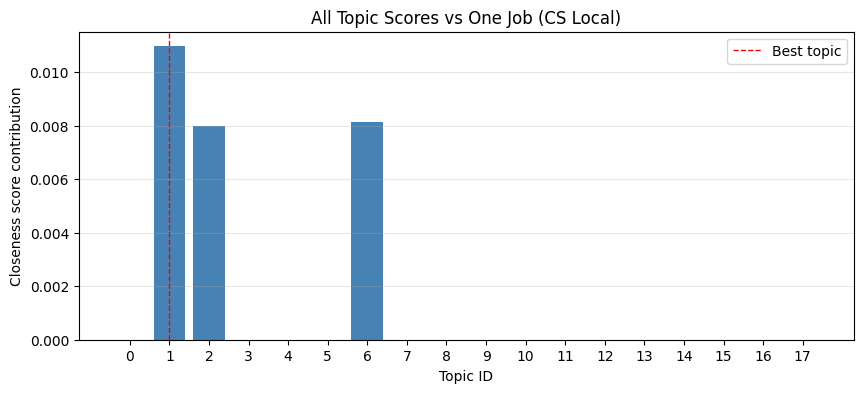

Job title: Software Engineer/ Developer
Dataset: CS Local
Best topic: 1 | Best score: 0.011
Second score: 0.0081 | Margin: 0.0028


In [24]:
# Pick a job to compare against all topics
# You can replace this query to inspect any specific title.
QUERY_TITLE = 'software engineer'
SOURCE = 'CS'  # 'CS' or 'IT'

pool = cs_all_scored if SOURCE == 'CS' else it_all_scored
topic_word_probs = cs_topic_word_probs if SOURCE == 'CS' else it_topic_word_probs
n_topics = CS_NUM_TOPICS if SOURCE == 'CS' else IT_NUM_TOPICS

match = pool[pool['job_title'].str.lower().str.contains(QUERY_TITLE.lower(), na=False)].head(1)
if len(match) == 0:
    match = pool.nlargest(1, 'best_score')

job = match.iloc[0]
scores = job['topic_scores']
topic_ids = list(range(n_topics))
vals = [scores.get(t, 0.0) for t in topic_ids]

plt.figure(figsize=(10, 4))
plt.bar(topic_ids, vals, color='steelblue')
plt.axvline(int(job['best_topic']), color='red', linestyle='--', linewidth=1, label='Best topic')
plt.title(f"All Topic Scores vs One Job ({job['dataset']})")
plt.xlabel('Topic ID')
plt.ylabel('Closeness score contribution')
plt.xticks(topic_ids)
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.show()

print('Job title:', job['job_title'])
print('Dataset:', job['dataset'])
print('Best topic:', int(job['best_topic']), '| Best score:', round(float(job['best_score']), 4))
print('Second score:', round(float(job['second_score']), 4), '| Margin:', round(float(job['margin']), 4))

## 4) Diagnostics: What Drives Final Dataset Scores?

Useful diagnostics:
- Mean best score
- Mean margin (confidence gap)
- Weak alignment rate (docs below dataset median best score)
- Topic concentration (whether many docs collapse to a few topics)

In [25]:
def summarize_scored(scored_df):
    best_topic_counts = scored_df['best_topic'].value_counts(normalize=True)
    concentration = float((best_topic_counts ** 2).sum())

    return {
        'rows': len(scored_df),
        'mean_best_score': scored_df['best_score'].mean(),
        'median_best_score': scored_df['best_score'].median(),
        'mean_margin': scored_df['margin'].mean(),
        'mean_norm_best': scored_df['normalized_best_score'].mean(),
        'weak_alignment_rate': scored_df['is_weak_alignment'].mean(),
        'topic_concentration_index': concentration,
    }

summary = pd.DataFrame([
    {'dataset': 'CS Local', **summarize_scored(cs_local_scored)},
    {'dataset': 'CS International', **summarize_scored(cs_intl_scored)},
    {'dataset': 'IT Local', **summarize_scored(it_local_scored)},
    {'dataset': 'IT International', **summarize_scored(it_intl_scored)},
]).round(4)

display(summary.sort_values('mean_best_score', ascending=False))

,dataset,rows,mean_best_score,median_best_score,mean_margin,mean_norm_best,weak_alignment_rate,topic_concentration_index
0,CS Local,13,0.0238,0.0231,0.0082,0.0035,0.4615,0.3254
1,CS International,1315,0.0235,0.0201,0.0078,0.0009,0.4973,0.1299
2,IT Local,13,0.0200,0.0198,0.0064,0.0017,0.4615,0.3254
3,IT International,1354,0.0194,0.0162,0.0062,0.0008,0.4830,0.1421


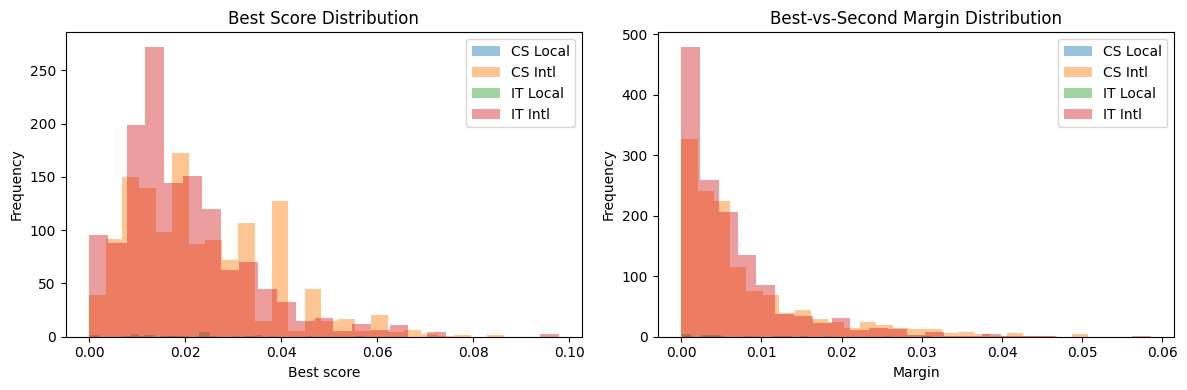

In [26]:
# Distribution view for quick comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name, sdf in [
    ('CS Local', cs_local_scored),
    ('CS Intl', cs_intl_scored),
    ('IT Local', it_local_scored),
    ('IT Intl', it_intl_scored),
]:
    axes[0].hist(sdf['best_score'], bins=25, alpha=0.45, label=name)

axes[0].set_title('Best Score Distribution')
axes[0].set_xlabel('Best score')
axes[0].set_ylabel('Frequency')
axes[0].legend()

for name, sdf in [
    ('CS Local', cs_local_scored),
    ('CS Intl', cs_intl_scored),
    ('IT Local', it_local_scored),
    ('IT Intl', it_intl_scored),
]:
    axes[1].hist(sdf['margin'], bins=25, alpha=0.45, label=name)

axes[1].set_title('Best-vs-Second Margin Distribution')
axes[1].set_xlabel('Margin')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()